# A Dollar Off \U0001F4B8
### On the ex-dividend day the price should fall by the dividend. Does it?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

It is nearly an accounting identity. A share about to pay you a dollar is worth a dollar more
than the same share after it has paid. So the morning the dividend detaches, the price should
open a dollar lower. In 1970 two economists measured it, found 78 cents, and started an argument
that is still running.

> \U0001F4D3 **This is the plain-language layer.** The estimator comparison, the bootstrap and
> the planted-truth control are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Should the price fall by the dividend? | Yes — it is close to an accounting identity. |
| Does it? | Roughly, but see how wide the uncertainty is. |
| Can you measure it precisely? | No, and that is the study's actual finding. |
| Is there a trade? | The gross edge is a few basis points; costs eat most of it. |

## 1 · The mechanics

Three dates matter. On the **declaration** date the company announces. On the **ex-date** the
stock starts trading *without* the right to the payment — buy it that morning and the dividend
goes to whoever sold it to you. On the **pay date** the cash arrives.

The ex-date is the interesting one. Overnight the share loses something worth exactly the
dividend, so the price should open lower by exactly the dividend.

In [2]:
from exday import data, strategy as st

bars = data.load_bars()
px = data.load_prices()
ev = st.build_events(bars, data.MARKET)
print(f"as-of {data.AS_OF} | {len(ev)} ex-dates on {ev['ticker'].nunique()} payers, "
      f"{ev.index[0].date()} -> {ev.index[-1].date()}")
print(f"median yield per event {ev['yield'].median():.3%}   "
      f"typical daily move {px[list(data.PAYERS)].pct_change().stack().std():.2%}")
print(ev.head()[["ticker", "price_cum", "price_ex", "dividend", "raw_ratio",
                 "adjusted_ratio"]].round(4).to_string())

as-of 2026-06-30 | 1025 ex-dates on 12 payers, 2005-01-06 -> 2026-06-15
median yield per event 0.850%   typical daily move 1.44%
           ticker  price_cum  price_ex  dividend  raw_ratio  adjusted_ratio
ex_date                                                                    
2005-01-06      T    19.2145   18.9955    0.3230     0.6781          0.9806
2005-01-06     VZ    35.9909   35.5682    0.3462     1.2208          1.7493
2005-01-19     PG    55.9900   56.6800    0.2500    -2.7600         -5.1033
2005-02-08    IBM    90.3728   89.9904    0.1721     2.2222          2.8346
2005-02-08    XOM    55.4000   55.7800    0.2700    -1.4074         -1.1682


## 2 · The scale problem, in one picture

Here is the difficulty in a single chart: the thing we are trying to measure is much smaller
than the daily noise it is hiding inside.

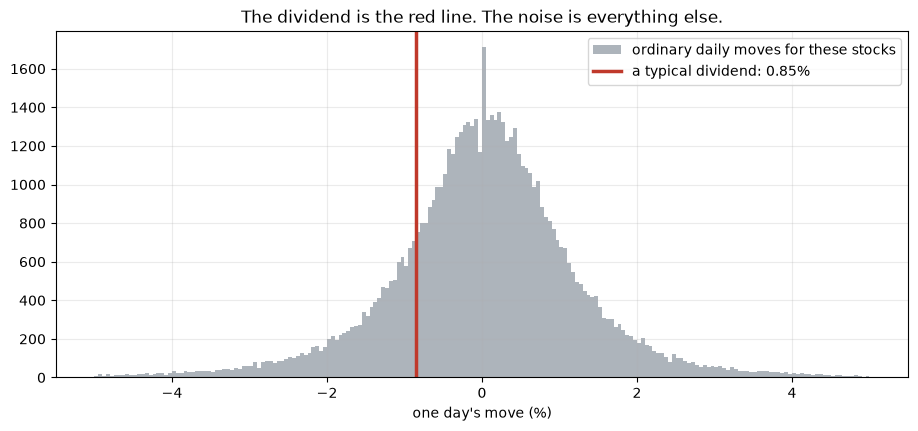

In [3]:
daily = px[list(data.PAYERS)].pct_change().stack().dropna()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(daily * 100, bins=200, range=(-5, 5), color="#8b949e", alpha=0.7,
        label="ordinary daily moves for these stocks")
ax.axvline(-ev["yield"].median() * 100, color="#c0392b", lw=2.5,
           label=f"a typical dividend: {ev['yield'].median():.2%}")
ax.set_xlabel("one day's move (%)"); ax.legend()
ax.set_title("The dividend is the red line. The noise is everything else.")
plt.show()

> \U0001F52C **For the quants.** This is why the per-event ratio `(P_cum − P_ex) / D` is such a
> hostile statistic: a numerator with a 1.2% standard deviation over a denominator of 0.7%. Its
> tails are heavy enough that averaging them is close to meaningless.

## 3 · What the individual events look like

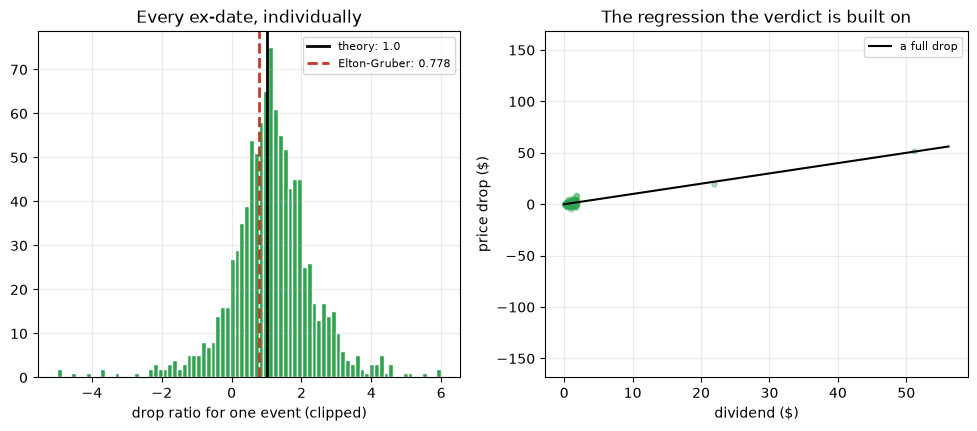

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(ev["adjusted_ratio"].clip(-5, 6), bins=80, color="#2ea44f", edgecolor="white")
axes[0].axvline(1.0, color="k", lw=2, label="theory: 1.0")
axes[0].axvline(st.ELTON_GRUBER_1970, color="#c0392b", lw=2, ls="--",
                label=f"Elton-Gruber: {st.ELTON_GRUBER_1970}")
axes[0].set_xlabel("drop ratio for one event (clipped)"); axes[0].legend(fontsize=8)
axes[0].set_title("Every ex-date, individually")
axes[1].scatter(ev["dividend"], ev["adjusted_drop"], s=12, alpha=0.35, color="#2ea44f")
lim = ev["dividend"].max() * 1.1
axes[1].plot([0, lim], [0, lim], color="k", lw=1.5, label="a full drop")
axes[1].set_xlabel("dividend ($)"); axes[1].set_ylabel("price drop ($)")
axes[1].set_ylim(-lim * 3, lim * 3); axes[1].legend(fontsize=8)
axes[1].set_title("The regression the verdict is built on")
plt.show()

## 4 · Four answers to one question

                             value                                      note
estimator                                                                   
mean of per-event ratios    1.1328  fat-tailed; dominated by small dividends
median of per-event ratios  1.1265  robust, but answers a different question
total drop / total dividend 1.1330     what a portfolio actually experienced
regression slope            1.0027                          t vs 1.0 = +0.14


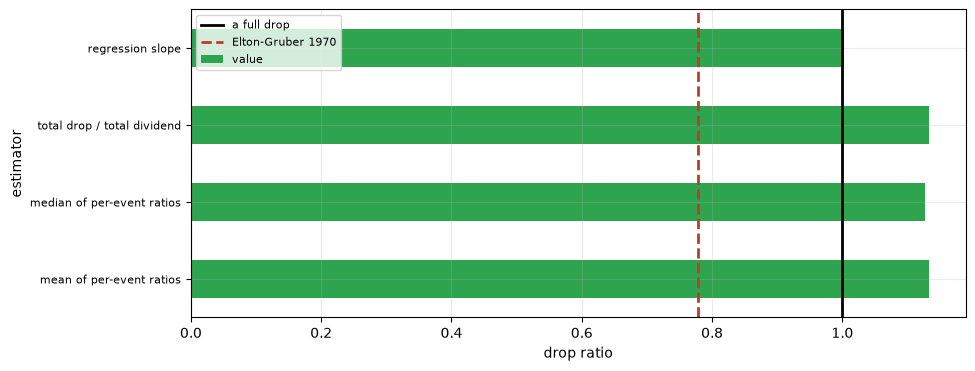


Spread between the four: 0.130


In [5]:
tbl = st.estimator_table(ev)
print(tbl.round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4))
tbl["value"].plot.barh(ax=ax, color="#2ea44f")
ax.axvline(1.0, color="k", lw=2, label="a full drop")
ax.axvline(st.ELTON_GRUBER_1970, color="#c0392b", lw=2, ls="--", label="Elton-Gruber 1970")
ax.set_xlabel("drop ratio"); ax.legend(fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
plt.show()
print(f"\nSpread between the four: {tbl['value'].max() - tbl['value'].min():.3f}")

> \U0001F52C **For the quants.** That spread is the study. It is larger than the difference
> between "a full drop" and the famous 0.778 — so a paper that quotes a drop ratio without
> saying which of these four it computed has not told you very much.

## 5 · Could you trade it?

In [6]:
for c in (0.0, 1.0, 2.0, 5.0, 10.0):
    r = st.capture_trade(ev, cost_bps=c)
    print(f"cost {c:5.1f} bps/side -> net {r['mean_net_bps']:+7.1f} bps/event, "
          f"t {r['t']:+5.2f}, hit rate {r['hit_rate']:.0%}")
r = st.capture_trade(ev, cost_bps=2.0)
print(f"\nper-event dispersion: {r['sd_bps']:.0f} bps against a mean of "
      f"{r['mean_net_bps']:+.1f} bps")

cost   0.0 bps/side -> net   -11.9 bps/event, t -3.03, hit rate 47%
cost   1.0 bps/side -> net   -13.9 bps/event, t -3.54, hit rate 46%
cost   2.0 bps/side -> net   -15.9 bps/event, t -4.04, hit rate 45%
cost   5.0 bps/side -> net   -21.9 bps/event, t -5.57, hit rate 42%
cost  10.0 bps/side -> net   -31.9 bps/event, t -8.12, hit rate 37%

per-event dispersion: 126 bps against a mean of -15.9 bps


## 6 · The verdict

**Signal: None.** Across **1025 ex-dates** on 12 mega-cap payers (2005-01-06 → 2026-06-15), a dollar of dividend took **1.003** of a dollar out of the price once that day's market move is removed (HC1 *t* against 1.0 = **+0.14**; against zero +53.13). The four defensible summaries of the same events disagree by more than the effect anyone is arguing about: the mean per-event ratio is +1.13, the median 1.13, total-drop-over-total-dividend 1.133, the regression slope 1.003. That spread is not sloppiness — the per-event ratio divides a 1.4% daily move by a 0.85% dividend, so 29% of individual events land outside the range [0, 2] entirely. Elton and Gruber's 0.778 sits outside the bootstrap interval [1.052, 1.218].

**Tradability: Mirage.** Buying at the cum close and selling at the ex close, keeping the dividend, earned **-11.9 bps** gross per event and **-15.9 bps** after 2 bps a side (*t* = -4.04, 45% of events profitable, dispersion 126 bps). The trade breaks even at -5.9 bps of round-trip cost, and at the 15% qualified-dividend rate a taxable holder nets -31.8 bps. The edge, if it is one, is smaller than the noise on a single event by a factor of 8.

## 7 · Going further \U0001F6AA

- **Use the opening price.** The drop happens at the auction; measuring to the ex-day *close*
  adds a whole day of noise for nothing.
- **High-yield names and REITs**, where the dividend is large enough to measure against the
  noise and where tax clienteles should bite hardest.
- **Special dividends**, which are big, irregular, and the cleanest natural experiment of all.